# MNIST Dataset Exploration
Sanity checks and visual inspection before training.
Run from the project root, or ensure the root is on `sys.path`.

In [2]:
import sys
from pathlib import Path

# Make sure the project root is on the path whether Jupyter starts in /notebooks or repo root.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'

from src.data_processing.dataset import load_dataset, create_splits, get_dataloaders, print_dataset_info
from src.data_processing.check_data import (
    show_samples,
    plot_batch,
    plot_label_distribution,
    plot_preprocessing_comparison,
)

%matplotlib inline


## 1. Dataset Info
Confirm sizes, image shape, and class range.

In [3]:
print_dataset_info(data_dir=str(DATA_DIR))


Dataset: MNIST
Train size: 60000
Test size: 10000
Image shape: torch.Size([1, 28, 28])
Sample label: 5
Number of classes: 10


## 2. Sample Images
A 3×3 grid of the first training examples. Saved to `outputs/sample_mnist.png`.

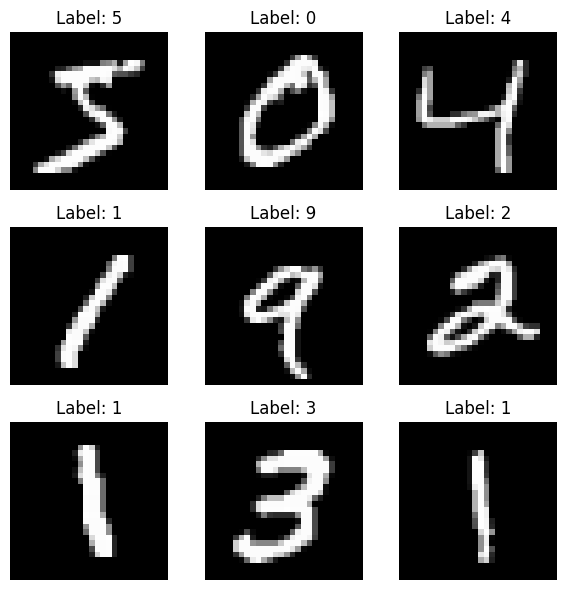

In [4]:
show_samples(data_dir=str(DATA_DIR), save_path=str(OUTPUT_DIR / 'sample_mnist.png'))


## 3. Batch Preview
Pull one batch from the train DataLoader and display 16 images. Saved to `outputs/batch_sample.png`.

Classes: 10
Batch shape: torch.Size([64, 1, 28, 28])  |  dtype: torch.float32
Pixel range: [-1.000, 1.000]  (expect ~[-1, 1] after normalization)


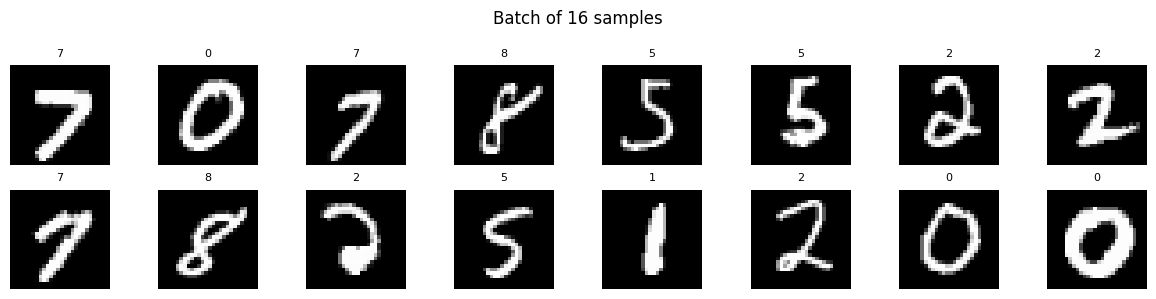

In [5]:
train_loader, val_loader, test_loader, num_classes = get_dataloaders(data_dir=str(DATA_DIR))

images, labels = next(iter(train_loader))
print(f'Classes: {num_classes}')
print(f'Batch shape: {images.shape}  |  dtype: {images.dtype}')
print(f'Pixel range: [{images.min():.3f}, {images.max():.3f}]  (expect ~[-1, 1] after normalization)')

plot_batch(train_loader, n=16, save_path=str(OUTPUT_DIR / 'batch_sample.png'))


## 4. Label Distribution
Check for class imbalance across train / validation / test splits. Saved to `outputs/label_distribution.png`.

Classes:    10
Train:      54,000 samples
Validation: 6,000 samples
Test:       10,000 samples


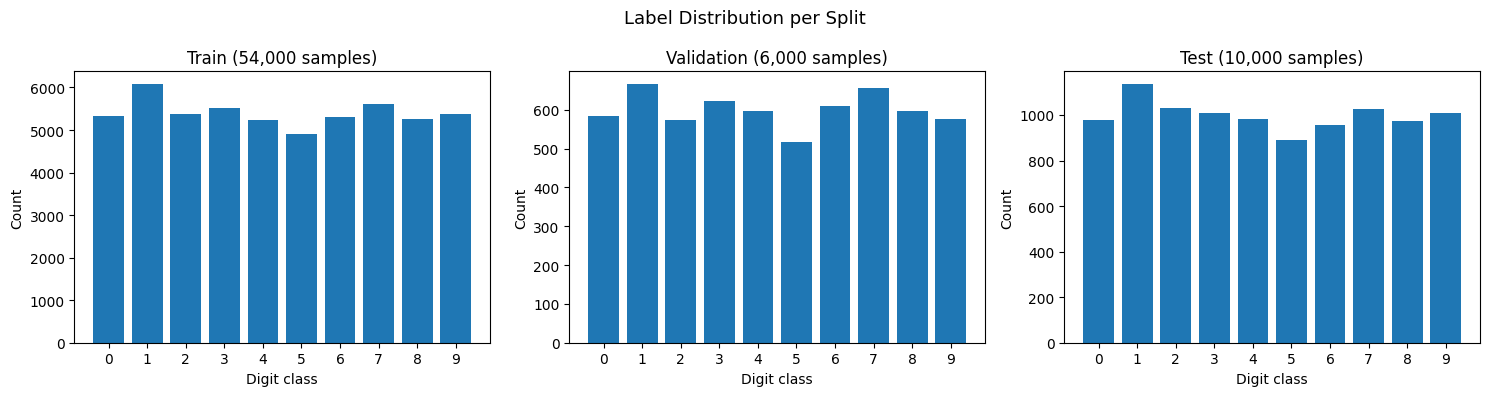

In [6]:
full_train, test_dataset, num_classes = load_dataset(dataset_name='mnist', data_dir=str(DATA_DIR))
train_subset, val_subset = create_splits(full_train)

print(f'Classes:    {num_classes}')
print(f'Train:      {len(train_subset):,} samples')
print(f'Validation: {len(val_subset):,} samples')
print(f'Test:       {len(test_dataset):,} samples')

plot_label_distribution(
    train_subset, val_subset, test_dataset,
    save_path=str(OUTPUT_DIR / 'label_distribution.png')
)


## 5. Preprocessing Verification
Side-by-side comparison of raw pixels vs. normalized pixels. Confirms the transform pipeline is working correctly. Saved to `outputs/preprocessing_comparison.png`.

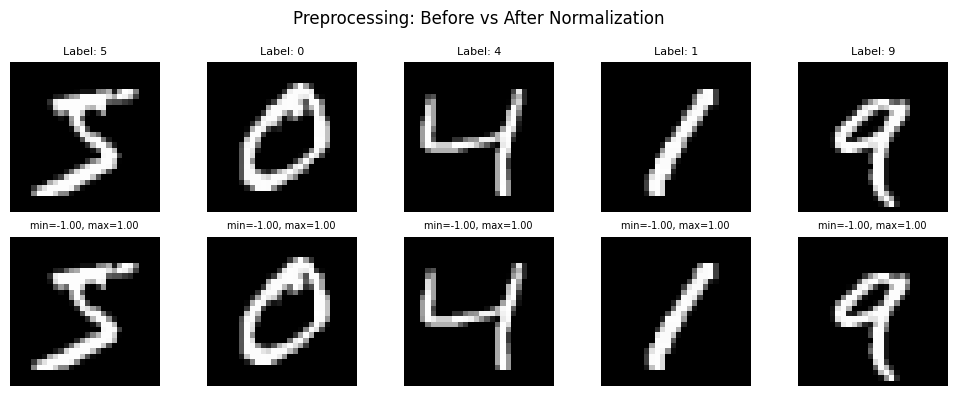

In [7]:
plot_preprocessing_comparison(n=5, data_dir=str(DATA_DIR), save_path=str(OUTPUT_DIR / 'preprocessing_comparison.png'))


## Summary

| Check | Expected |
|---|---|
| Train / Val / Test sizes | 54,000 / 6,000 / 10,000 |
| Image shape | `(1, 28, 28)` |
| Pixel range after normalization | `[-1.0, 1.0]` |
| Classes | 0–9, roughly balanced |

Figures saved to `outputs/`.